In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random

from src.graph.graph_level_measures import compute_graph_properties
from src.graph.graph_utils import detect_communities, attach_communities, separate_graphs_if_needed
from src.graph.centralities.betweenness import cal_betweenness_centrality
from src.graph.centralities.k_core import cal_k_core
from src.graph.centralities.k_truss import cal_k_truss
from src.graph.centralities.comm_centrality import comm_centrality
from src.graph.centralities.modularity_vitality import modularity_vitality

class CentralitySpec:
    def __init__(self, func, graph, require_simple_graph=False, extra={}):
        self.func = func
        self.graph = graph
        self.require_simple_graph = require_simple_graph
        self.extra = extra
        
    def cal_centrality(self):
        multi_graph = isinstance(self.graph, (nx.MultiGraph, nx.MultiDiGraph))
        
        if multi_graph and self.require_simple_graph:
            # skip if it must be simple but our graph isn’t
            return None
        
        return self.func(self.graph)

==>> graph_properties: {'name': None, 'number_of_nodes': 90, 'number_of_edges': 467, 'max_degree': 18, 'avg_degree': 10.377777777777778, 'transitivity': 0.33866782006920415, 'density': 0.11660424469413233, 'mixing_parameter': 0.023554603854389723}


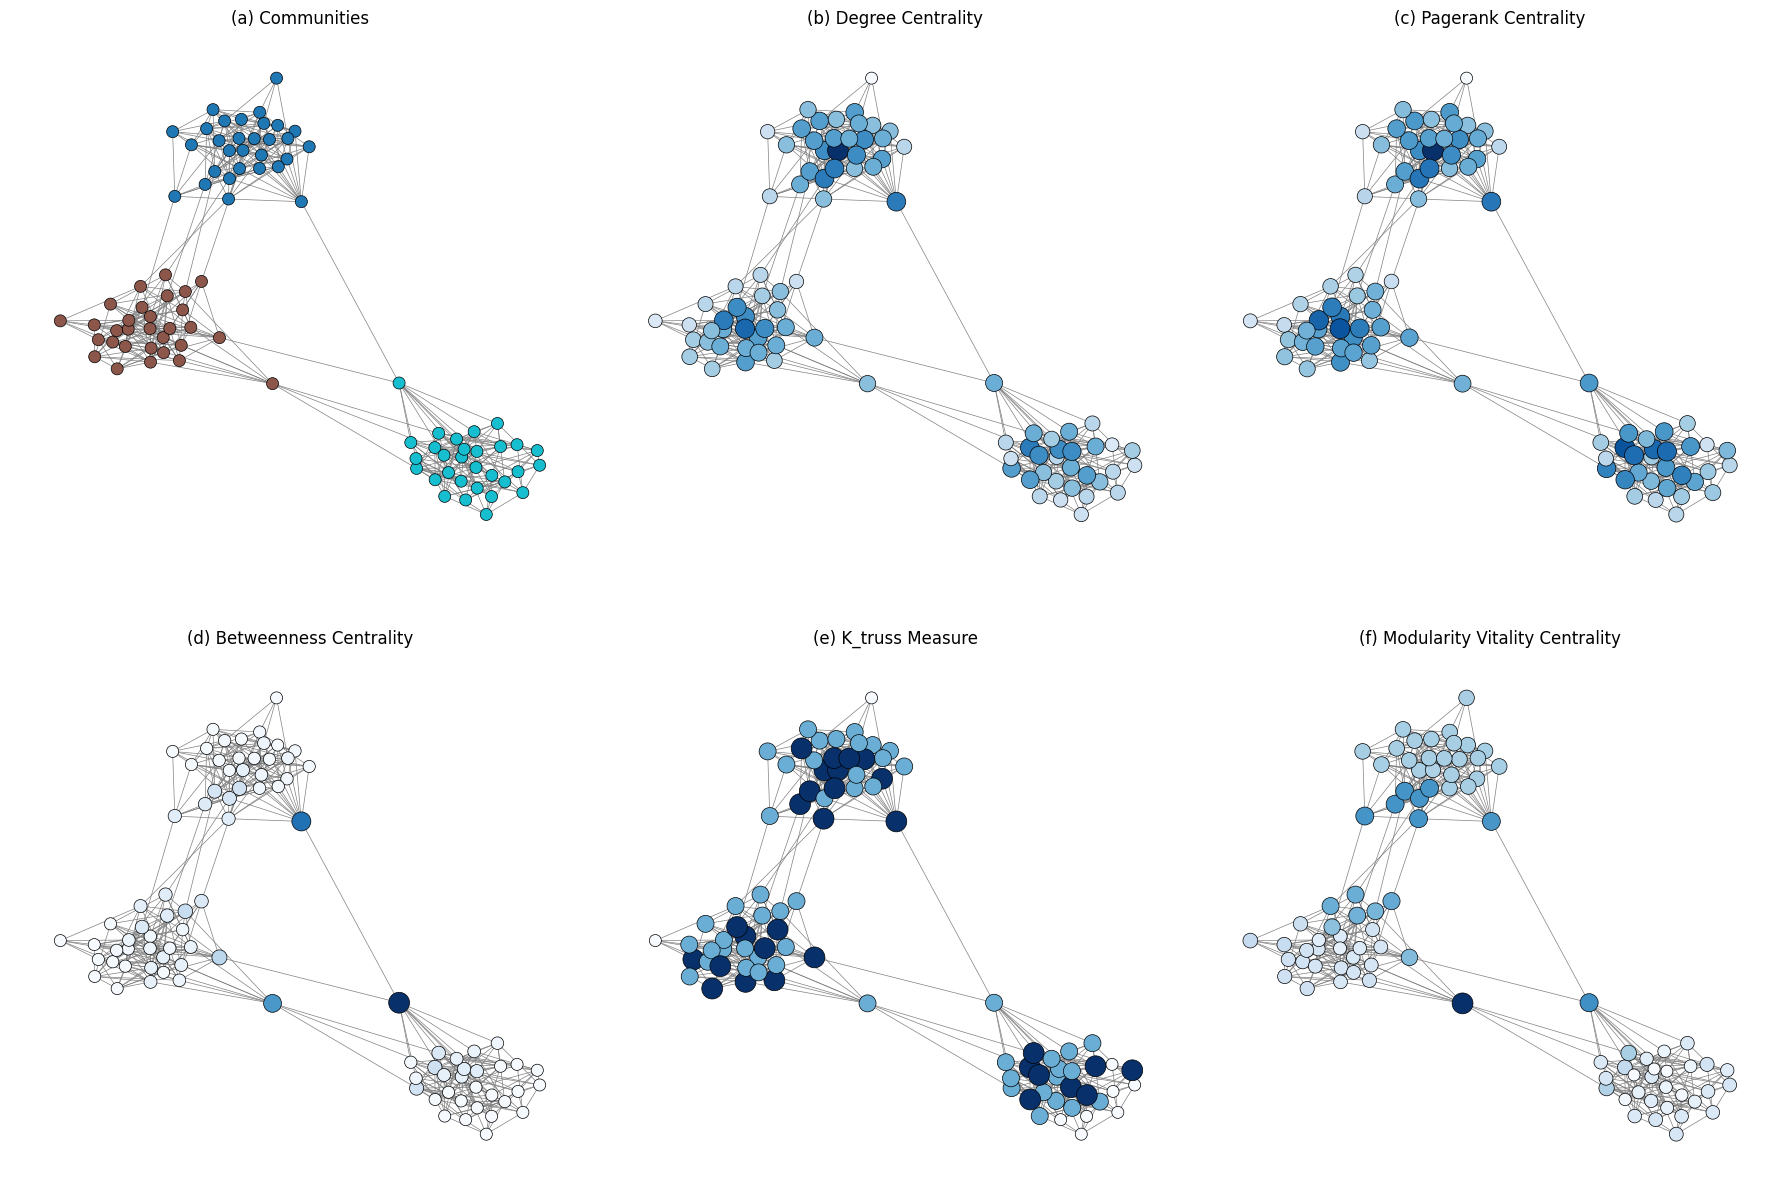

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import random

from src.graph.graph_level_measures import compute_graph_properties
from src.graph.graph_utils import detect_communities, attach_communities, separate_graphs_if_needed
from src.graph.centralities.betweenness import cal_betweenness_centrality
from src.graph.centralities.k_core import cal_k_core
from src.graph.centralities.k_truss import cal_k_truss
from src.graph.centralities.comm_centrality import comm_centrality
from src.graph.centralities.modularity_vitality import modularity_vitality

class CentralitySpec:
    def __init__(self, func, graph, require_simple_graph=False, extra={}):
        self.func = func
        self.graph = graph
        self.require_simple_graph = require_simple_graph
        self.extra = extra
        
    def cal_centrality(self):
        multi_graph = isinstance(self.graph, (nx.MultiGraph, nx.MultiDiGraph))
        
        if multi_graph and self.require_simple_graph:
            # skip if it must be simple but our graph isn’t
            return None
        
        return self.func(self.graph)


# 1. Generate graph via Stochastic Block Model
sizes = [30, 30, 30]
probs = [[0.8, 0.05, 0.02], [0.05, 0.7, 0.05], [0.02, 0.05, 0.6]]
G = nx.stochastic_block_model(sizes, probs, seed=42)

# 2. Detect communities for coloring

communities, G1, part = detect_communities(G)

# communities = list(nx.community.greedy_modularity_communities(G))
community_map = {n: idx for idx, com in enumerate(communities) for n in com}

# 3. Separate and sample edges (20% intra, 5% inter)
intra_edges = [e for e in G.edges() if community_map[e[0]] == community_map[e[1]]]
inter_edges = [e for e in G.edges() if community_map[e[0]] != community_map[e[1]]]
sampled_intra = random.sample(intra_edges, int(len(intra_edges) * 0.5))
sampled_inter = random.sample(inter_edges, int(len(inter_edges) * 0.1))
sampled_edges = sampled_intra + sampled_inter

# 4. Prune to sampled edges and largest connected component
G.remove_edges_from([e for e in G.edges() if e not in sampled_edges])
largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()
sampled_edges = [e for e in sampled_edges if e[0] in G and e[1] in G]


graph_properties = compute_graph_properties(G)
print(f"==>> graph_properties: {graph_properties}")

density = graph_properties["density"]
transitivity = graph_properties["transitivity"]
mixing_param = graph_properties["mixing_parameter"]



communities, G1, part = detect_communities(G)

community_labels = attach_communities(G, communities)


intra_graph, inter_graph = separate_graphs_if_needed(G, communities)

CENTRALITY_SPECS = {
    "betweenness":      CentralitySpec(cal_betweenness_centrality, G),
    "pagerank":         CentralitySpec(nx.pagerank, G, False, {"alpha": 0.85}),
    "local_betweenness": CentralitySpec(cal_betweenness_centrality, intra_graph),
    "global_betweenness": CentralitySpec(cal_betweenness_centrality, inter_graph),
    "degree":           CentralitySpec(nx.degree_centrality, G),
    "local_degree":     CentralitySpec(nx.degree_centrality, intra_graph),
    "global_degree":    CentralitySpec(nx.degree_centrality, inter_graph),
    "eigenvector":      CentralitySpec(nx.eigenvector_centrality, G, True, {"max_iter": 600}),
    "local_eigenvector": CentralitySpec(nx.eigenvector_centrality, intra_graph, True, {"max_iter": 600}),
    "global_eigenvector": CentralitySpec(nx.eigenvector_centrality, inter_graph, True, {"max_iter": 600}),
    "closeness":        CentralitySpec(nx.closeness_centrality, G),
    "local_closeness":  CentralitySpec(nx.closeness_centrality, intra_graph),
    "global_closeness": CentralitySpec(nx.closeness_centrality, inter_graph),
    "local_pagerank":   CentralitySpec(nx.pagerank, intra_graph, False, {"alpha": 0.85}),
    "global_pagerank":  CentralitySpec(nx.pagerank, inter_graph, False, {"alpha": 0.85}),
    "k_core":           CentralitySpec(cal_k_core, G, True),
    "k_truss":          CentralitySpec(cal_k_truss, G),
    "Comm":             CentralitySpec(lambda g: comm_centrality(g, community_labels), G),
    "mv":               CentralitySpec(lambda g: modularity_vitality(G1, part), G),
}

# 5. Compute and normalize centralities
# def normalize(vals, low=0.5, high=2.0):
def normalize(vals, low=1, high=3.0):
    vmin, vmax = min(vals), max(vals)
    return [low + (v - vmin) / (vmax - vmin) * (high - low) for v in vals]

def cal_centrality(G, name, func):
    return func(G)
                      
metrics = {}
metrics['Community'] = ([75] * G.number_of_nodes(), [community_map[n] for n in G.nodes()])

cn_measures = ["degree", "pagerank", "betweenness", "k_truss", "mv"]
for measure in cn_measures:
    spec = CENTRALITY_SPECS.get(measure)
    values = spec.cal_centrality()
    metrics[measure] = ([v * 75 for v in normalize(list(values.values()))], normalize(list(values.values())))
    
# 6. Plot in 2 rows × 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
metrics_keys = list(metrics.keys())
titles = ["(a) Communities", "(b) Degree Centrality", "(c) Pagerank Centrality", "(d) Betweenness Centrality", "(e) K_truss Measure", "(f) Modularity Vitality Centrality"]

i = 0
for ax, mk in zip(axes, metrics_keys):
    sizes, colors = metrics[mk]
    # Choose colormap based on metric
    cmap = plt.cm.Blues if mk not in ['Uniform', 'Community'] else (plt.cm.tab10 if mk=='Community' else None)
    nx.draw(
        G, pos=nx.spring_layout(G, seed=42), ax=ax,
        node_size=sizes,
        node_color=colors,
        cmap=cmap,
        edgecolors='black',
        linewidths=0.5,
        with_labels=False,
        edgelist=sampled_edges,
        edge_color='gray',
        width=0.5
    )
    ax.set_title(titles[i])
    i += 1

plt.tight_layout(h_pad=5.0)
plt.show()
